In [1]:
import os
from pathlib import Path
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
from torchsummary import summary
import evaluate
from PIL import Image, ImageFile
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.pytorch
import dagshub
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [2]:
dagshub.init(repo_owner='RichardHolzhofer', repo_name='tomato_disease_detection_project', mlflow=True)

Accessing as RichardHolzhofer

Initialized MLflow to track repo "RichardHolzhofer/tomato_disease_detection_project"

Repository RichardHolzhofer/tomato_disease_detection_project initialized!

#### Downloading dataset

In [ ]:
kaggle_path = kagglehub.dataset_download("cookiefinder/tomato-disease-multiple-sources")

dataset_path = Path(kaggle_path)
print(f"Dataset downloaded to: {dataset_path}")

Path to dataset files: C:\Users\hrichard\.cache\kagglehub\datasets\cookiefinder\tomato-disease-multiple-sources\versions\1
Dataset downloaded to: C:\Users\hrichard\.cache\kagglehub\datasets\cookiefinder\tomato-disease-multiple-sources\versions\1


In [5]:
# Using validation set as test set for performance evaluation
print(f"Folders in dataset path: {os.listdir(dataset_path)}")
train_folder_path = os.path.join(dataset_path, "train")
test_folder_path = os.path.join(dataset_path, "valid")
print(f"Train folder path: {train_folder_path}")
print(f"Test folder path: {test_folder_path}")

Folders in dataset path: ['train', 'valid']
Train folder path: C:\Users\hrichard\.cache\kagglehub\datasets\cookiefinder\tomato-disease-multiple-sources\versions\1\train
Test folder path: C:\Users\hrichard\.cache\kagglehub\datasets\cookiefinder\tomato-disease-multiple-sources\versions\1\valid


In [6]:
def get_dataset_info(path):
    """
    Creates a pandas DataFrame containing image file paths and their corresponding disease labels.

    Args:
        path (str): Path to the dataset folder

    Returns:
        df (pd.DataFrame): DataFrame with 'path' and 'label' columns for each image file found in subdirectories
    """
    data = []

    folder_path = Path(path)

    # Looping through subdirectories (disease classes)
    for class_dir in folder_path.iterdir():
        if class_dir.is_dir():
            label = class_dir.name
            # Looping through image files in the class directory
            for filepath in class_dir.iterdir():
                if filepath.is_file() and filepath.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    data.append({'path': str(filepath), 'label': label})

    df = pd.DataFrame(data)
    return df

### Checking image distributions in train and test datasets

In [46]:
train_dataset = get_dataset_info(train_folder_path)
print("Train dataset:\n\n", train_dataset["label"].value_counts())

Train dataset:

 label
Late_blight                             3113
healthy                                 3051
Septoria_leaf_spot                      2882
Bacterial_spot                          2826
Leaf_Mold                               2754
Early_blight                            2455
Tomato_mosaic_virus                     2153
Tomato_Yellow_Leaf_Curl_Virus           2039
Target_Spot                             1827
Spider_mites Two-spotted_spider_mite    1747
powdery_mildew                          1004
Name: count, dtype: int64


In [8]:
test_df = get_dataset_info(test_folder_path)
print("Test dataset:\n\n", test_df["label"].value_counts())

Test dataset:

 label
healthy                                 806
Late_blight                             792
Septoria_leaf_spot                      746
Leaf_Mold                               739
Bacterial_spot                          732
Early_blight                            643
Tomato_mosaic_virus                     584
Tomato_Yellow_Leaf_Curl_Virus           498
Target_Spot                             457
Spider_mites Two-spotted_spider_mite    435
powdery_mildew                          252
Name: count, dtype: int64


### Creating mapping dictionaries (label to id)

In [ ]:
def create_label_to_id(df):
    """
    Creates a mapping dictionary from disease labels to numeric IDs.
    
    Maps unique disease labels from a DataFrame to sequential integer IDs (0, 1, 2, ...).
    Labels are sorted alphabetically to ensure consistent mapping across different calls.

    Args:
        df (pd.DataFrame): DataFrame containing a 'label' column with disease class names

    Returns:
        dict: Dictionary mapping label names (str) to numeric IDs (int), sorted alphabetically by label name
        
    Example:
        If df has labels ['Healthy', 'Powdery Mildew', 'Early Blight'],
        returns: {'Early Blight': 0, 'Healthy': 1, 'Powdery Mildew': 2}
    """
    label_to_id = {name: id for id, name in enumerate(sorted(df["label"].unique()))}
    return label_to_id

In [47]:
train_and_validation_classes = create_label_to_id(train_dataset)

print(pd.Series(train_and_validation_classes))

Bacterial_spot                           0
Early_blight                             1
Late_blight                              2
Leaf_Mold                                3
Septoria_leaf_spot                       4
Spider_mites Two-spotted_spider_mite     5
Target_Spot                              6
Tomato_Yellow_Leaf_Curl_Virus            7
Tomato_mosaic_virus                      8
healthy                                  9
powdery_mildew                          10
dtype: int64


In [11]:
test_classes = create_label_to_id(test_df)

print(pd.Series(test_classes))

Bacterial_spot                           0
Early_blight                             1
Late_blight                              2
Leaf_Mold                                3
Septoria_leaf_spot                       4
Spider_mites Two-spotted_spider_mite     5
Target_Spot                              6
Tomato_Yellow_Leaf_Curl_Virus            7
Tomato_mosaic_virus                      8
healthy                                  9
powdery_mildew                          10
dtype: int64


### Creating train and validation datasets

In [12]:
from sklearn.model_selection import train_test_split

# Split train_dataset into train and validation sets
train_df, valid_df = train_test_split(train_dataset, test_size=0.25, random_state=42, stratify=train_dataset['label'])

print("Train set size:", len(train_df))
print("Validation set size:", len(valid_df))
print("Test set size:", len(test_df))
print("\nTrain set class distribution:\n", train_df['label'].value_counts())
print("\nValidation set class distribution:\n", valid_df['label'].value_counts())
print("\nTest set class distribution:\n", test_df['label'].value_counts())

Train set size: 19388
Validation set size: 6463
Test set size: 6684

Train set class distribution:
 label
Late_blight                             2335
healthy                                 2288
Septoria_leaf_spot                      2161
Bacterial_spot                          2120
Leaf_Mold                               2066
Early_blight                            1841
Tomato_mosaic_virus                     1615
Tomato_Yellow_Leaf_Curl_Virus           1529
Target_Spot                             1370
Spider_mites Two-spotted_spider_mite    1310
powdery_mildew                           753
Name: count, dtype: int64

Validation set class distribution:
 label
Late_blight                             778
healthy                                 763
Septoria_leaf_spot                      721
Bacterial_spot                          706
Leaf_Mold                               688
Early_blight                            614
Tomato_mosaic_virus                     538
Tomato_Yellow_Leaf_Cur

### Checking data distribution

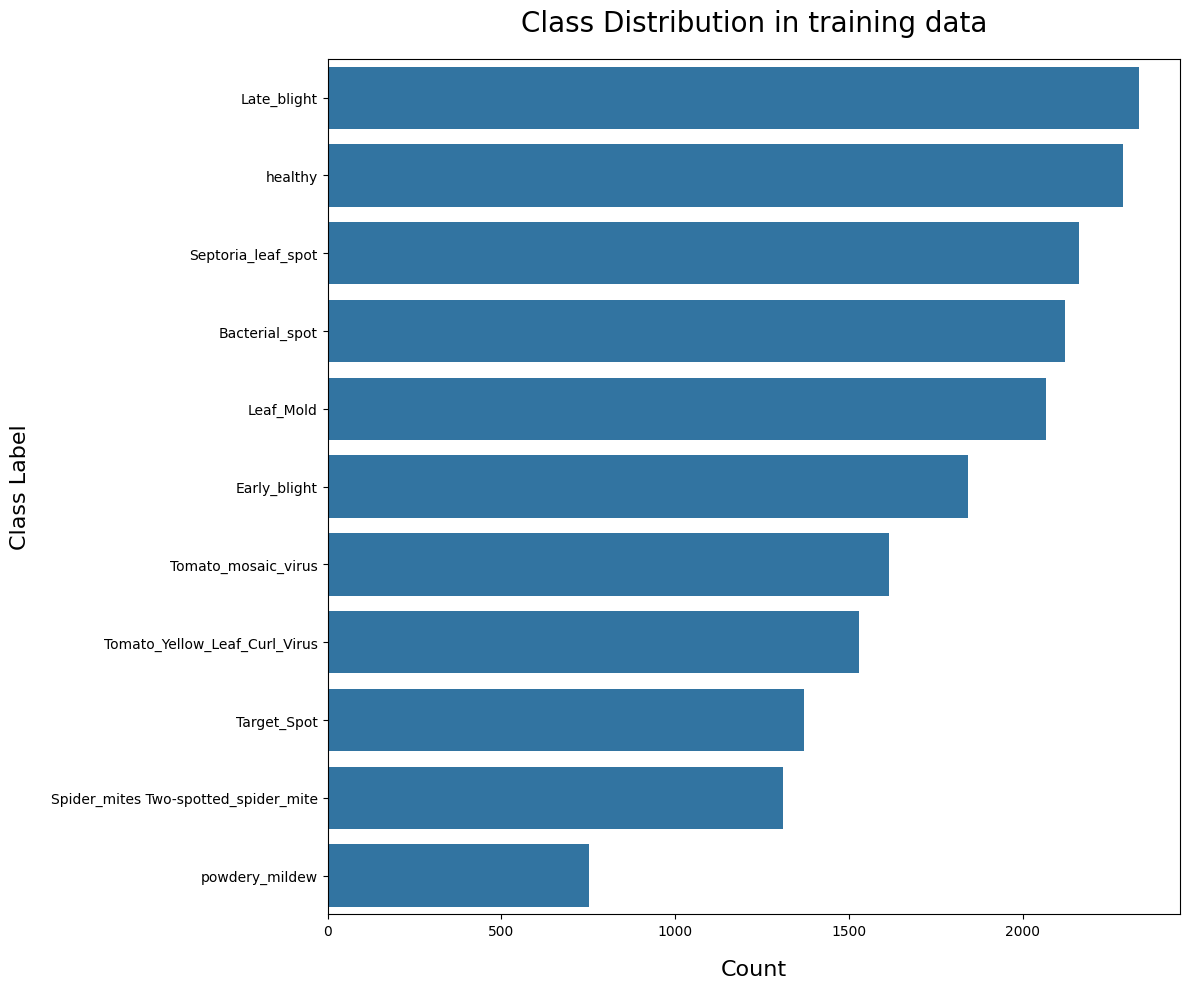

In [52]:
fig, ax = plt.subplots(figsize=(12, 10))

order = train_df['label'].value_counts().index
sns.countplot(data=train_df, y='label', order=order, ax=ax)
ax.set_title('Class Distribution in training data', fontsize=20, pad=20)
ax.set_xlabel('Count', fontsize=16, labelpad=15)
ax.set_ylabel('Class Label', fontsize=16, labelpad=15)

plt.tight_layout()
plt.show()

In [ ]:
def calculate_class_weights(df):
    """
    Calculates class weights to handle imbalanced datasets.
    
    Computes inverse frequency weights for each class so that minority classes
    receive higher weights during training, helping the model learn from underrepresented
    disease categories.

    Args:
        df (pd.DataFrame): DataFrame containing a 'label' column with disease class names

    Returns:
        np.ndarray: Array of weights corresponding to each class, ordered by class ID
        
    Notes:
        - Weight formula: total_samples / (num_classes * samples_per_class)
        - Classes with fewer samples receive higher weights
        - Useful for weighted CrossEntropyLoss
    """
    
    samples_per_class = train_df["label"].value_counts()
    num_classes = len(samples_per_class)
    total_samples = samples_per_class.sum()

    weights = total_samples / (num_classes * samples_per_class)

    print(weights, end="\n\n")
    
    return weights.values

In [53]:
train_weights = calculate_class_weights(train_df)

train_weights

label
Late_blight                             0.754837
healthy                                 0.770343
Septoria_leaf_spot                      0.815616
Bacterial_spot                          0.831389
Leaf_Mold                               0.853120
Early_blight                            0.957385
Tomato_mosaic_virus                     1.091359
Tomato_Yellow_Leaf_Curl_Virus           1.152744
Target_Spot                             1.286530
Spider_mites Two-spotted_spider_mite    1.345455
powdery_mildew                          2.340698
Name: count, dtype: float64



array([0.75483745, 0.77034329, 0.81561567, 0.83138937, 0.85311977,
       0.95738482, 1.09135941, 1.15274392, 1.28652953, 1.34545455,
       2.34069781])

In [ ]:
def show_samples(df, num_samples=9):
    """
    Displays a grid of random sample images from a dataset with their disease labels.
    
    Randomly selects images from the provided DataFrame and visualizes them in a 3x3 grid.
    Each subplot shows the image with its corresponding disease label as the title.
    Handles missing or corrupted image files gracefully with error messages.

    Args:
        df (pd.DataFrame): DataFrame containing 'path' and 'label' columns for images
        num_samples (int): Number of images to display. Default is 9 (3x3 grid). 
                          Will display fewer if dataset has fewer samples.

    Returns:
        None. Displays the visualization using matplotlib.
        
    Raises:
        Prints error messages for any images that fail to load.
        
    Example:
        show_samples(train_df, num_samples=9)  # Display 9 random training images
        show_samples(valid_df, num_samples=4)  # Display 4 random validation images
    """
    if df.empty:
        print("No data to visualize.")
        return
        
    plt.figure(figsize=(15, 12))
    # Sample random images
    sample_df = df.sample(min(num_samples, len(df)))
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        try:
            img = Image.open(row['path'])
            plt.subplot(3, 3, i + 1)
            plt.imshow(img)
            plt.title(row['label'])
            plt.axis('off')
        except Exception as e:
            print(f"Error loading image {row['path']}: {e}")
            
    plt.tight_layout()
    plt.show()

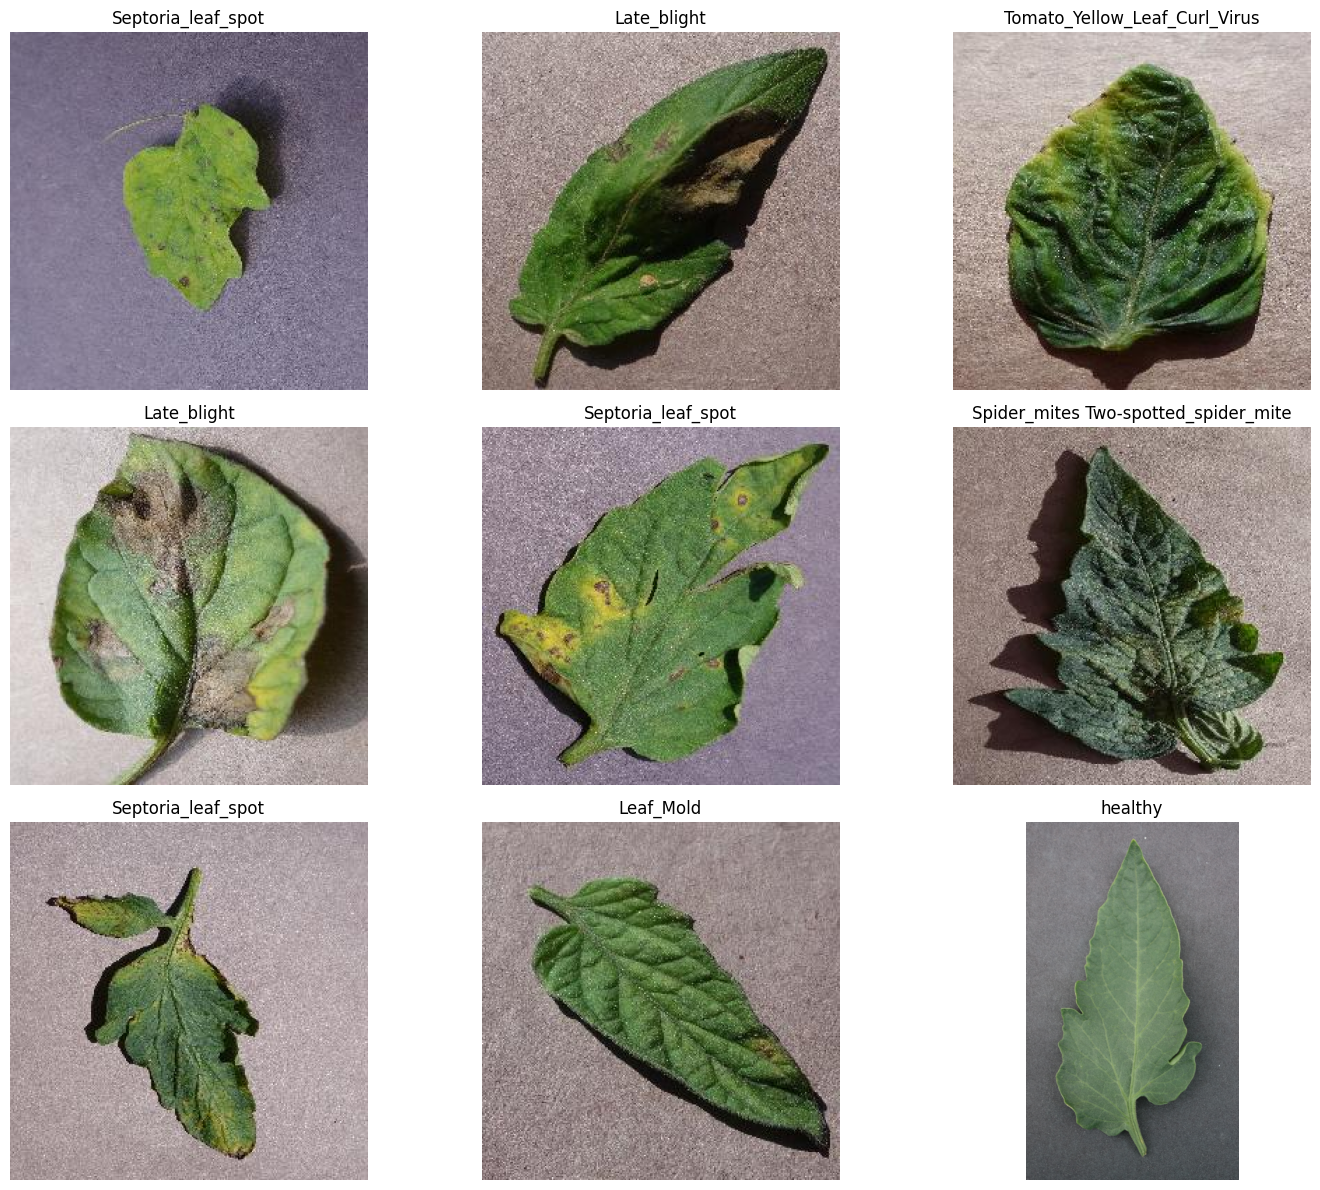

In [19]:
train_samples = show_samples(train_df)

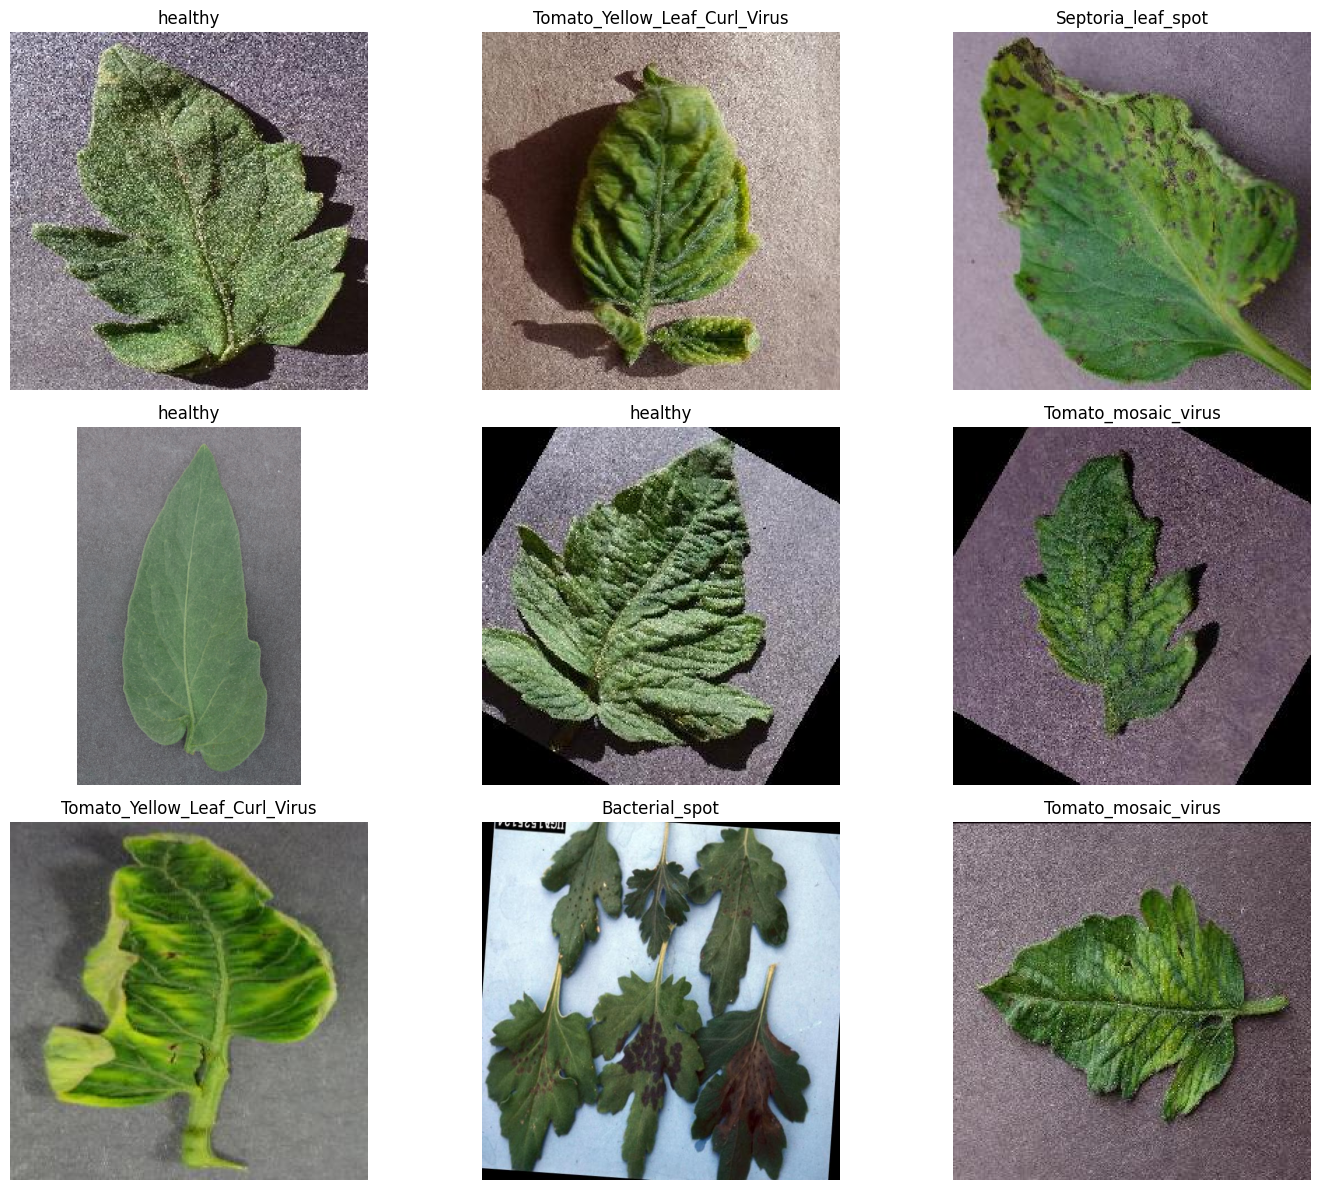

In [18]:
valid_samples = show_samples(valid_df)

In [20]:
def get_image_size_distribution(df, path_col, name="Train"):
    widths = []
    heights = []

    for path in df[path_col]:
        try:
            with Image.open(path) as img:
                widths.append(img.width)
                heights.append(img.height)
        except:
            pass

    data = pd.DataFrame({'Width': widths, 'Height': heights})
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    
    sns.boxenplot(data=data[['Width']], ax=axes[0])
    axes[0].set_title('Image Width Distribution')
    axes[0].set_ylabel("Width in pixels")

    sns.boxenplot(data=data[['Height']], ax=axes[1])
    axes[1].set_title('Image Height Distribution')
    axes[1].set_ylabel("Height in pixels")
    
    plt.tight_layout()
    plt.show()

    print(f"{name} dataset - Average Width in pixels: {np.mean(widths):.2f}")
    print(f"{name} dataset - Median Width in pixels: {np.median(widths):.2f}")
    print(f"{name} dataset - Average Height in pixels: {np.mean(heights):.2f}")
    print(f"{name} dataset - Median Height in pixels: {np.median(heights):.2f}")
    print(f"{name} dataset - Min Dimensions in pixels: {min(widths)}x{min(heights)}")
    print(f"{name} dataset - Max Dimensions in pixels: {max(widths)}x{max(heights)}")

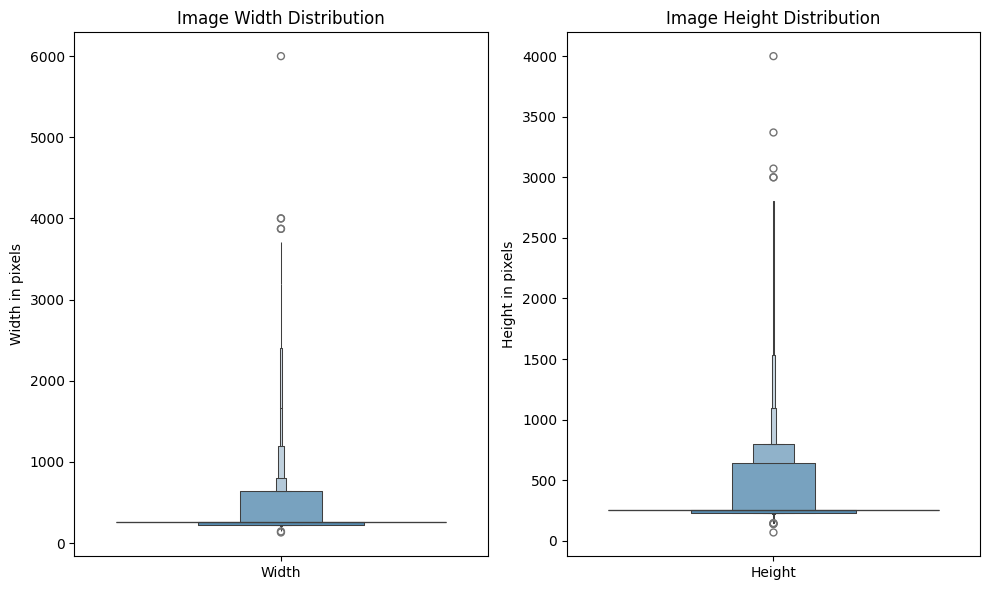

Train dataset - Average Width in pixels: 292.72
Train dataset - Median Width in pixels: 256.00
Train dataset - Average Height in pixels: 301.86
Train dataset - Median Height in pixels: 256.00
Train dataset - Min Dimensions in pixels: 130x69
Train dataset - Max Dimensions in pixels: 6000x4000


In [21]:
get_image_size_distribution(df=train_df, path_col="path", name="Train")

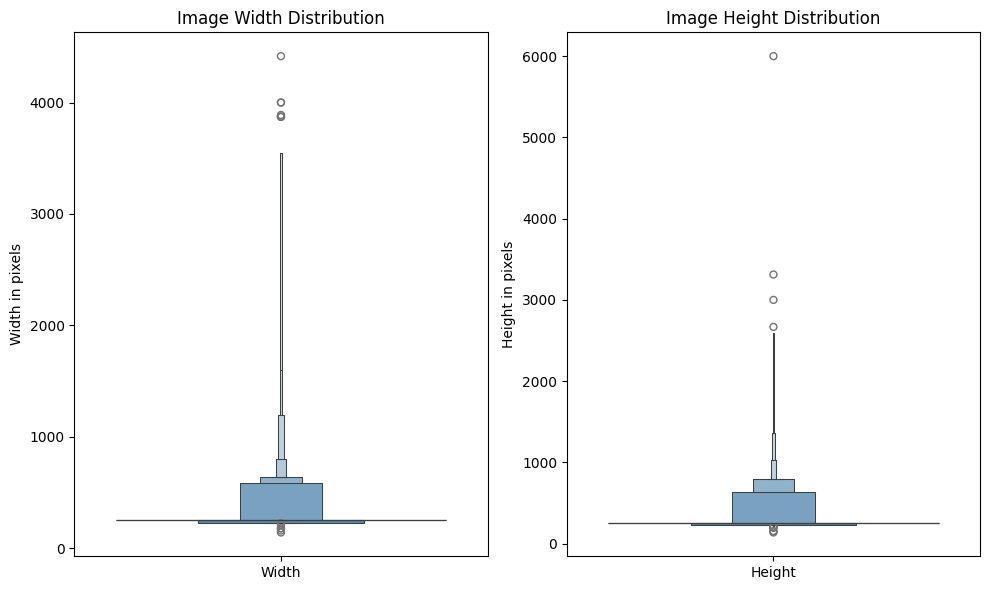

Validation dataset - Average Width in pixels: 291.90
Validation dataset - Median Width in pixels: 256.00
Validation dataset - Average Height in pixels: 300.55
Validation dataset - Median Height in pixels: 256.00
Validation dataset - Min Dimensions in pixels: 142x137
Validation dataset - Max Dimensions in pixels: 4416x6000


In [22]:
get_image_size_distribution(df=valid_df, path_col="path", name="Validation")

# Custom dataset creation

In [23]:
class ImageDataset(Dataset):
  def __init__(self, df, label_to_id, transform=None):
    self.df = df
    self.label_to_id = label_to_id
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_path = self.df.iloc[idx]["path"]
    image = Image.open(img_path).convert("RGB")
    label = self.label_to_id[self.df.iloc[idx]["label"]]

    if self.transform:
      image = self.transform(image)

    return image, label

In [24]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.485, 0.456, 0.406], std= [0.229, 0.224, 0.225])]
)

In [25]:
train_image_dataset = ImageDataset(df=train_df, label_to_id=train_and_validation_classes, transform=transform)
validation_image_dataset = ImageDataset(df=valid_df, label_to_id=train_and_validation_classes, transform=transform)
test_image_dataset = ImageDataset(df=test_df, label_to_id=test_classes, transform=transform)


In [26]:
train_image_loader = DataLoader(dataset=train_image_dataset, batch_size=32, shuffle=True)
validation_image_loader = DataLoader(dataset=validation_image_dataset, batch_size=32, shuffle=True)
test_image_loader = DataLoader(dataset=test_image_dataset, batch_size=32, shuffle=True)

In [27]:
for img, id in train_image_loader:
  print(img.shape, id.shape)
  break

torch.Size([32, 3, 256, 256]) torch.Size([32])


In [28]:
train_dict = {v:k for k, v in train_image_dataset.label_to_id.items()}
test_dict = {v:k for k, v in test_image_dataset.label_to_id.items()}
validation_dict = {v:k for k, v in validation_image_dataset.label_to_id.items()}

Image shape in train_image_loader:
torch.Size([32, 3, 256, 256]) - (batch size, color channels, height, width)
Image shape: (256, 256, 3)
Disease name: Spider_mites Two-spotted_spider_mite, disease id: 5


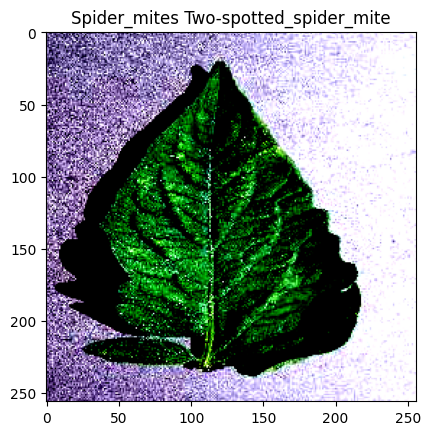

In [29]:
for images, labels in train_image_loader:
  print(f"Image shape in train_image_loader:\n{images.shape} - (batch size, color channels, height, width)")
  img = images[0].numpy()
  label = labels[0].item()
  img = np.transpose(img, (1,2,0))
  print(f"Image shape: {img.shape}")
  print(f"Disease name: {train_dict[label]}, disease id: {label}")
  plt.title(train_dict[label])
  plt.imshow(img)
  break

In [30]:
class CustomCnnModel(nn.Module):
  def __init__(self,input_dim, num_classes):
    super(CustomCnnModel, self).__init__()
    self.input_dim = input_dim
    self.num_classes = num_classes

    self.conv_layers = nn.Sequential(
        # C1
        nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
        # 128x128x3 --> 3x3x3x32 --> wxhx32
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C2
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C3
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C4
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self._to_linear = None
    self._get_conv_output(self.input_dim)

    self.fc_layers = nn.Sequential(
        nn.Linear(self._to_linear, 512),
        nn.ReLU(),
        # nn.Dropout(0.2)
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Linear(128, self.num_classes),
    )

    # 256 x 12 x 12

  def _get_conv_output(self, input_dim=128):
    with torch.no_grad():
      dummy_input = torch.zeros(1,3, input_dim, input_dim)
      output = self.conv_layers(dummy_input)
      self._to_linear = output.view(1, -1).size(1)

  def forward(self,x):
    x = self.conv_layers(x)
    x = x.view(x.size(0), -1)
    x = self.fc_layers(x)
    return x

In [31]:
class CustomCnnModelNew(nn.Module):
    def __init__(self, input_dim, num_classes):
        super(CustomCnnModelNew, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # C1 to C4 remain the same
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # REPLACE Flattening logic with GAP
        self.global_pool = nn.AdaptiveAvgPool2d(1) 

        self.fc_layers = nn.Sequential(
            nn.Linear(256, 512), # Input is now just the channel count (256)
            nn.ReLU(),
            nn.Dropout(0.3),     # Increased slightly to 0.3 for better regularization
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.global_pool(x)  # Result shape: [Batch, 256, 1, 1]
        x = torch.flatten(x, 1)  # Result shape: [Batch, 256]
        x = self.fc_layers(x)
        return x

In [32]:
num_train_classes = len(train_and_validation_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomCnnModel(input_dim=256, num_classes=num_train_classes).to(device)
new_model = CustomCnnModelNew(input_dim=256, num_classes=num_train_classes).to(device)

print(device)

cuda


In [33]:
print(summary(model, (3,256,256)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             896
       BatchNorm2d-2         [-1, 32, 256, 256]              64
              ReLU-3         [-1, 32, 256, 256]               0
         MaxPool2d-4         [-1, 32, 128, 128]               0
            Conv2d-5         [-1, 64, 128, 128]          18,496
       BatchNorm2d-6         [-1, 64, 128, 128]             128
              ReLU-7         [-1, 64, 128, 128]               0
         MaxPool2d-8           [-1, 64, 64, 64]               0
            Conv2d-9          [-1, 128, 64, 64]          73,856
      BatchNorm2d-10          [-1, 128, 64, 64]             256
             ReLU-11          [-1, 128, 64, 64]               0
        MaxPool2d-12          [-1, 128, 32, 32]               0
           Conv2d-13          [-1, 256, 32, 32]         295,168
      BatchNorm2d-14          [-1, 256,

In [34]:
print(summary(new_model, (3,256,256)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             896
       BatchNorm2d-2         [-1, 32, 256, 256]              64
              ReLU-3         [-1, 32, 256, 256]               0
         MaxPool2d-4         [-1, 32, 128, 128]               0
            Conv2d-5         [-1, 64, 128, 128]          18,496
       BatchNorm2d-6         [-1, 64, 128, 128]             128
              ReLU-7         [-1, 64, 128, 128]               0
         MaxPool2d-8           [-1, 64, 64, 64]               0
            Conv2d-9          [-1, 128, 64, 64]          73,856
      BatchNorm2d-10          [-1, 128, 64, 64]             256
             ReLU-11          [-1, 128, 64, 64]               0
        MaxPool2d-12          [-1, 128, 32, 32]               0
           Conv2d-13          [-1, 256, 32, 32]         295,168
      BatchNorm2d-14          [-1, 256,

In [35]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [35]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_score = None
        self.counter = 0
        self. best_model_state = None
        
    def step(self, score, model):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
            self.best_model_state = model.state_dict()
        else:
            self.counter += 1
            
        return self.counter >= self.patience

In [36]:
def log_confusion_matrix(preds, true_labels, class_names, epoch=None, test=False):

    cm = confusion_matrix(true_labels, preds)
    fig, ax = plt.subplots(figsize=(12, 10))
    
    sns.heatmap(data=cm,
                annot=True,
                fmt='d',
                cmap='Blues', 
                xticklabels=class_names,
                yticklabels=class_names,
                ax=ax
                )
    
    if test:
        title = 'Confusion Matrix - Test results'
        filename = "confusion_matrices/cm_test_set.png"
    else:
        title = f'Confusion Matrix - Epoch {epoch+1}'
        filename = f"confusion_matrices/cm_epoch_{epoch+1}.png"
        
        ax.set_title(title, fontsize=20, pad=20)
        ax.set_ylabel('Actual', fontsize=16, labelpad=15)
        ax.set_xlabel('Predicted', fontsize=16, labelpad=15)
        ax.tick_params(axis='both', which='major', labelsize=12)
        
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
        plt.tight_layout()
        
        mlflow.log_figure(fig, filename)
    
    return fig

In [37]:
def my_train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    class_names,
    epochs=10,
    save_path="best_model.pth",
    patience=5
    ):
    
    last_matrix = None
    
    with mlflow.start_run():
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)
        mlflow.log_params(
            {"epochs": epochs,
             "patience": patience,
             "optimizer": optimizer,
             "criterion": criterion,
             "scheduler": scheduler
             }
            )
        
        # Load metrics from evaluate library
        accuracy_metric = evaluate.load('accuracy')
        f1_metric = evaluate.load('f1')
        
        history = {
            "train_loss":[],
            "val_loss":[],
            "val_acc":[],
            "val_f1_weighted":[],
            "val_f1_macro":[]
            }
        
        early_stopping = EarlyStopping(patience=patience)

        train_bar = tqdm(range(epochs), desc="Total Progress", leave=True)
        for epoch in train_bar:
            print(f"Epoch {epoch + 1}/{epochs}")
            print("-" * 10)
        
            model.train()
            
            train_loss_list = []
            train_preds = []
            train_labels = []
            
            for images, labels in tqdm(train_loader, desc="Training", leave=False):
                images = images.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                
                train_loss_list.append(loss.item())
                preds = outputs.argmax(dim=1)
                train_preds.extend(preds.cpu().numpy())
                train_labels.extend(labels.cpu().numpy())

                train_bar.set_postfix(loss=loss.item())

            epoch_train_loss = np.mean(train_loss_list)
            train_acc_results = accuracy_metric.compute(predictions=train_preds, references=train_labels)
            epoch_train_acc = train_acc_results['accuracy']

            model.eval()
            
            val_bar = tqdm(val_loader, desc="Validation", leave=False)
            val_preds = []
            val_labels = []
            val_loss_list = []

            with torch.inference_mode():
                for images, labels in val_bar:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    
                    # Collect predictions and labels for metrics
                    preds = outputs.argmax(dim=1)
                    val_preds.extend(preds.cpu().numpy())
                    val_labels.extend(labels.cpu().numpy())
                    val_loss_list.append(loss.item())

                epoch_val_loss = np.mean(val_loss_list)
                
                # Compute accuracy
                val_acc_results = accuracy_metric.compute(predictions=val_preds, references=val_labels)
                epoch_val_acc = val_acc_results['accuracy']
                
                # Compute F1 scores using evaluate library
                f1_results_weighted = f1_metric.compute(predictions=val_preds, references=val_labels, average='weighted')
                f1_results_macro = f1_metric.compute(predictions=val_preds, references=val_labels, average='macro')
                epoch_val_f1_weighted = f1_results_weighted['f1']
                epoch_val_f1_macro = f1_results_macro['f1']

                history['train_loss'].append(epoch_train_loss)
                history['val_loss'].append(epoch_val_loss)
                history['val_acc'].append(epoch_val_acc)
                history['val_f1_weighted'].append(epoch_val_f1_weighted)
                history['val_f1_macro'].append(epoch_val_f1_macro)
                
                
                mlflow.log_metrics({
                    "train_loss": epoch_train_loss,
                    "val_loss": epoch_val_loss,
                    "val_acc": epoch_val_acc,
                    "val_f1_weighted": epoch_val_f1_weighted,
                    "val_f1_macro": epoch_val_f1_macro
                    },
                    step=epoch)
                
                if last_matrix is not None:
                    plt.close(last_matrix)
                
                
                last_matrix = log_confusion_matrix(
                    preds=val_preds,
                    true_labels=val_labels,
                    class_names=class_names,
                    epoch=epoch
                    )
            
                if scheduler:
                    if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                        scheduler.step(epoch_val_loss)
                    else:
                        scheduler.step()

                print(f'Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}')
                print(f'Val F1 Weighted: {epoch_val_f1_weighted:.4f} | Val F1 Macro: {epoch_val_f1_macro:.4f}')
    
                # --- Early Stopping with weighted F1 ---
                if early_stopping.step(epoch_val_f1_weighted, model):
                    print(f'Early stopping triggered after epoch {epoch + 1}')
                    model.load_state_dict(early_stopping.best_model_state)
                    break
                
                # Save best model
                torch.save(model.state_dict(), save_path)

            print(f'Best Validation F1 Weighted: {early_stopping.best_score:.4f}')
            
        model.to("cpu")
        mlflow.pytorch.log_model(pytorch_model=model,
                                 registered_model_name=f"{Path(save_path).name}",
                                 artifact_path="model"
                                 )

    return model, history, last_matrix


In [79]:
model = CustomCnnModel(input_dim=256, num_classes=num_train_classes)
optimizer = optim.Adam(model.parameters(),lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
criterion = nn.CrossEntropyLoss()

new_model, new_history = my_train_model(
    model,
    train_image_loader,
    validation_image_loader,
    criterion,
    optimizer,
    scheduler,
    epochs=1,
    save_path="models/custom_model_1.pth",
    patience=2)

Total Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/1
----------


Total Progress: 100%|██████████| 1/1 [01:16<00:00, 76.11s/it, loss=1.38]
2026/02/17 21:03:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Total Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/1
----------


...

Epoch 1/1
----------


Total Progress: 100%|██████████| 1/1 [01:16<00:00, 76.11s/it, loss=1.38]
2026/02/17 21:03:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train Loss: 1.4052 | Val Loss: 0.7058 | Val Acc: 0.7509
Val F1 Weighted: 0.7474 | Val F1 Macro: 0.7439
Best Validation F1 Weighted: 0.7474


2026/02/17 21:03:56 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/02/17 21:03:56 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.1+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.9.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/02/17 21:03:59 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.1+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.9.1' without the local version label to make it

🏃 View run delicate-fox-916 at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0/runs/7af108f8fc0a4bdbbd0b6a2df85eb791
🧪 View experiment at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0


Total Progress:   0%|          | 0/2 [00:00<?, ?it/s]

Epoch 1/2
----------


Total Progress:  50%|█████     | 1/2 [01:15<01:15, 75.00s/it, loss=0.774]

Train Loss: 1.3196 | Val Loss: 0.9325 | Val Acc: 0.6310
Val F1 Weighted: 0.6255 | Val F1 Macro: 0.6201
Best Validation F1 Weighted: 0.6255
Epoch 2/2
----------


Total Progress: 100%|██████████| 2/2 [02:30<00:00, 75.40s/it, loss=1]    
2026/02/19 18:42:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train Loss: 0.8645 | Val Loss: 0.6354 | Val Acc: 0.7575
Val F1 Weighted: 0.7622 | Val F1 Macro: 0.7533
Best Validation F1 Weighted: 0.7622


2026/02/19 18:42:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/02/19 18:42:57 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.1+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.9.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/02/19 18:43:00 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.1+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.9.1' without the local version label to make it

🏃 View run abrasive-skunk-716 at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0/runs/c0017a0296f74ec78cc2c3a64f509135
🧪 View experiment at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0


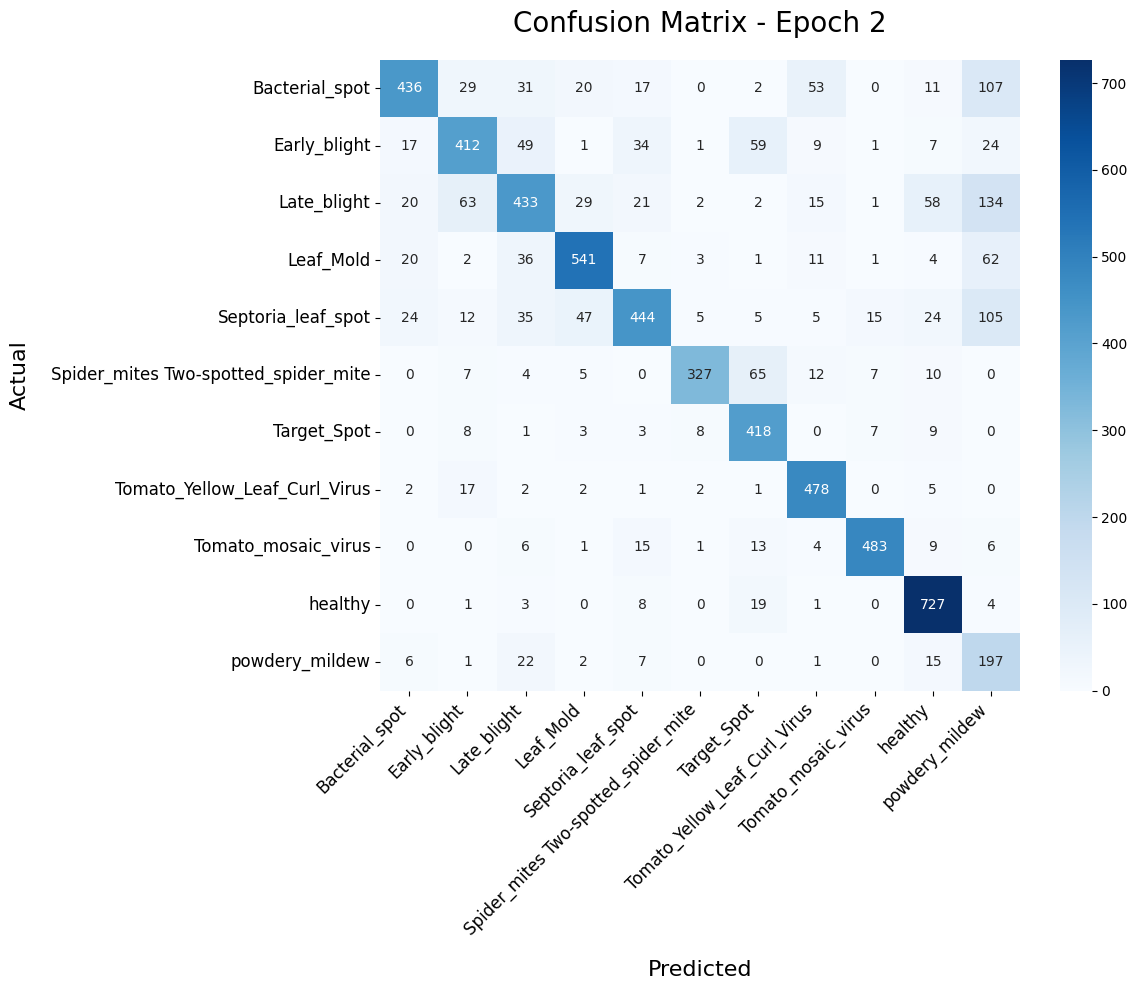

In [ ]:
new_model = CustomCnnModelNew(input_dim=256, num_classes=num_train_classes).to(device)
optimizer = optim.Adam(new_model.parameters(),lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)
weights_tensor = torch.tensor(train_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)

custom_model, custom_history, custom_conf_mat = my_train_model(
    model=new_model,
    train_loader=train_image_loader,
    val_loader=validation_image_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    class_names=train_and_validation_classes,
    epochs=2,
    save_path="models/custom_model_1_new_with_matrix_2.pth",
    patience=5)

In [ ]:
model = CustomCnnModel(input_dim=256, num_classes=num_train_classes).to(device=device)

model.load_state_dict(torch.load("models/cnn_model_40.pth"))
print(model.state_dict())

OrderedDict({'conv_layers.0.weight': tensor([[[[ 2.9330e-01,  2.1746e-01, -1.6581e-01],
          [ 2.4497e-01,  5.1329e-02, -1.0908e-01],
          [ 4.9218e-02,  2.1559e-01,  1.8592e-01]],

         [[ 8.7114e-02, -1.0092e-01, -2.3236e-01],
          [ 4.3467e-02,  5.1658e-03, -7.2543e-02],
          [ 2.0570e-01, -4.3913e-02, -5.0060e-02]],

         [[-1.3847e-01, -5.7294e-02, -3.1922e-01],
          [-1.2285e-01, -1.9118e-02, -2.8795e-01],
          [-3.0611e-01, -2.4585e-01, -3.2857e-01]]],


        [[[ 3.7864e-01,  3.0093e-01,  4.8078e-01],
          [ 1.2182e-01,  2.6926e-01,  2.1756e-01],
          [-1.9262e-01, -2.1373e-02,  1.1905e-01]],

         [[-1.4936e-01,  2.4008e-01,  1.4857e-01],
          [-1.9905e-01,  4.2946e-02, -3.8501e-02],
          [-4.4536e-02, -2.3325e-01, -1.9123e-01]],

         [[-4.2413e-02, -2.2338e-02, -1.0692e-02],
          [-1.0652e-01,  1.4369e-01,  2.2477e-01],
          [-1.2131e-01,  1.1290e-01, -6.7944e-02]]],


        [[[-6.0126e-01, -6.97

In [44]:
criterion = nn.CrossEntropyLoss()

In [38]:
def evaluate_model(model, test_loader, criterion):
    # Evaluate model
    ImageFile.LOAD_TRUNCATED_IMAGES = True # Must be set because test set (validation folder) contains truncated images

    with mlflow.start_run():
        mlflow.set_tag("model_type","efficientnet_b0_fine_tuned")
        
        accuracy_metric = evaluate.load('accuracy')
        f1_metric = evaluate.load('f1')

        model.eval()
        
        mlflow.log_param("criterion", criterion)
                    
        test_bar = tqdm(test_loader, desc="Test", leave=False)
        test_preds = []
        test_labels = []
        test_loss_list = []

        with torch.inference_mode():
            for images, labels in test_bar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                # Collect predictions and labels for metrics
                preds = outputs.argmax(dim=1)
                test_preds.extend(preds.cpu().numpy())
                test_labels.extend(labels.cpu().numpy())
                test_loss_list.append(loss.item())

            test_loss = np.mean(test_loss_list)
            
            # Compute accuracy
            test_acc_results = accuracy_metric.compute(predictions=test_preds, references=test_labels)
            test_acc = test_acc_results['accuracy']
            
            # Compute F1 scores using evaluate library
            f1_results_weighted = f1_metric.compute(predictions=test_preds, references=test_labels, average='weighted')
            f1_results_macro = f1_metric.compute(predictions=test_preds, references=test_labels, average='macro')
            test_f1_weighted = f1_results_weighted['f1']
            test_f1_macro = f1_results_macro['f1']
            
            mlflow.log_metrics({
                "test_loss": test_loss,
                "test_acc": test_acc,
                "test_f1_weighted": test_f1_weighted,
                "test_f1_macro": test_f1_macro
                }
                               )
            
        log_confusion_matrix(
            preds=test_preds, 
            true_labels=test_labels, 
            class_names=train_and_validation_classes,
            test=True
        )
            
        print(f"Loss on test set: {test_loss}")
        print(f"Accuracy score on test set: {test_acc*100:.2f}%")
        print(f"Weighted F1 score on test set: {test_f1_weighted*100:.2f}%")
        print(f"Macro F1 score on test set: {test_f1_macro*100:.2f}%")

In [48]:
evaluate_model(model=model, test_loader=test_image_loader, criterion=criterion)

Loss on test set: 0.5523741795978304
Accuracy score on test set: 90.65%
Weighted F1 score on test set: 90.67%
Macro F1 score on test set: 90.46%
🏃 View run wise-bird-121 at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0/runs/34f3c0a0b1f844e78cda9acbf83e826b
🧪 View experiment at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0


In [64]:
custom_model = custom_model.to(device)

evaluate_model(model=custom_model, test_loader=test_image_loader, criterion=criterion)

Loss on test set: 0.2529281024691876
Accuracy score on test set: 91.10%
Weighted F1 score on test set: 91.12%
Macro F1 score on test set: 90.69%
🏃 View run mercurial-turtle-833 at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0/runs/02cabc2001f14e9dbc0bc72117089084
🧪 View experiment at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0


# EfficientNet-B0 fine-tuning

In [39]:
efficientnet_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

for name, layer in efficientnet_model.named_children():
    if name == 'classifier':
        print(f"Layer: {layer}")
    #print(layer)
    #print("-" * 20)

Layer: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [40]:
for param in efficientnet_model.parameters():
    param.requires_grad = False

In [49]:
num_ftrs = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(num_ftrs, num_train_classes)
    )

In [43]:
efficientnet_model.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [47]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, efficientnet_model.parameters()), lr=0.001)
weights_tensor = torch.tensor(train_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

Total Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5
----------


Total Progress:  20%|██        | 1/5 [00:59<03:56, 59.14s/it, loss=0.631]

Train Loss: 0.9145 | Val Loss: 0.5263 | Val Acc: 0.8253
Val F1 Weighted: 0.8256 | Val F1 Macro: 0.8221
Best Validation F1 Weighted: 0.8256
Epoch 2/5
----------


Total Progress:  40%|████      | 2/5 [01:56<02:55, 58.38s/it, loss=0.729]

...

Total Progress: 100%|██████████| 5/5 [04:49<00:00, 57.90s/it, loss=0.496]
2026/02/19 21:25:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train Loss: 0.4534 | Val Loss: 0.3433 | Val Acc: 0.8742
Val F1 Weighted: 0.8743 | Val F1 Macro: 0.8730
Best Validation F1 Weighted: 0.8743


2026/02/19 21:25:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/02/19 21:25:57 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.1+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.9.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/02/19 21:26:01 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.24.1+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.24.1' without the local version la

🏃 View run dazzling-perch-172 at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0/runs/f6bf2c1c258c4dc7ad537ac349e13419
🧪 View experiment at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0


(EfficientNet(
   (features): Sequential(
     (0): Conv2dNormActivation(
       (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
       (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (2): SiLU(inplace=True)
     )
     (1): Sequential(
       (0): MBConv(
         (block): Sequential(
           (0): Conv2dNormActivation(
             (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
             (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
             (2): SiLU(inplace=True)
           )
           (1): SqueezeExcitation(
             (avgpool): AdaptiveAvgPool2d(output_size=1)
             (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
             (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
             (activation): SiLU(inplace=True)
             (scale_activation): Sigmoid()
           )
          

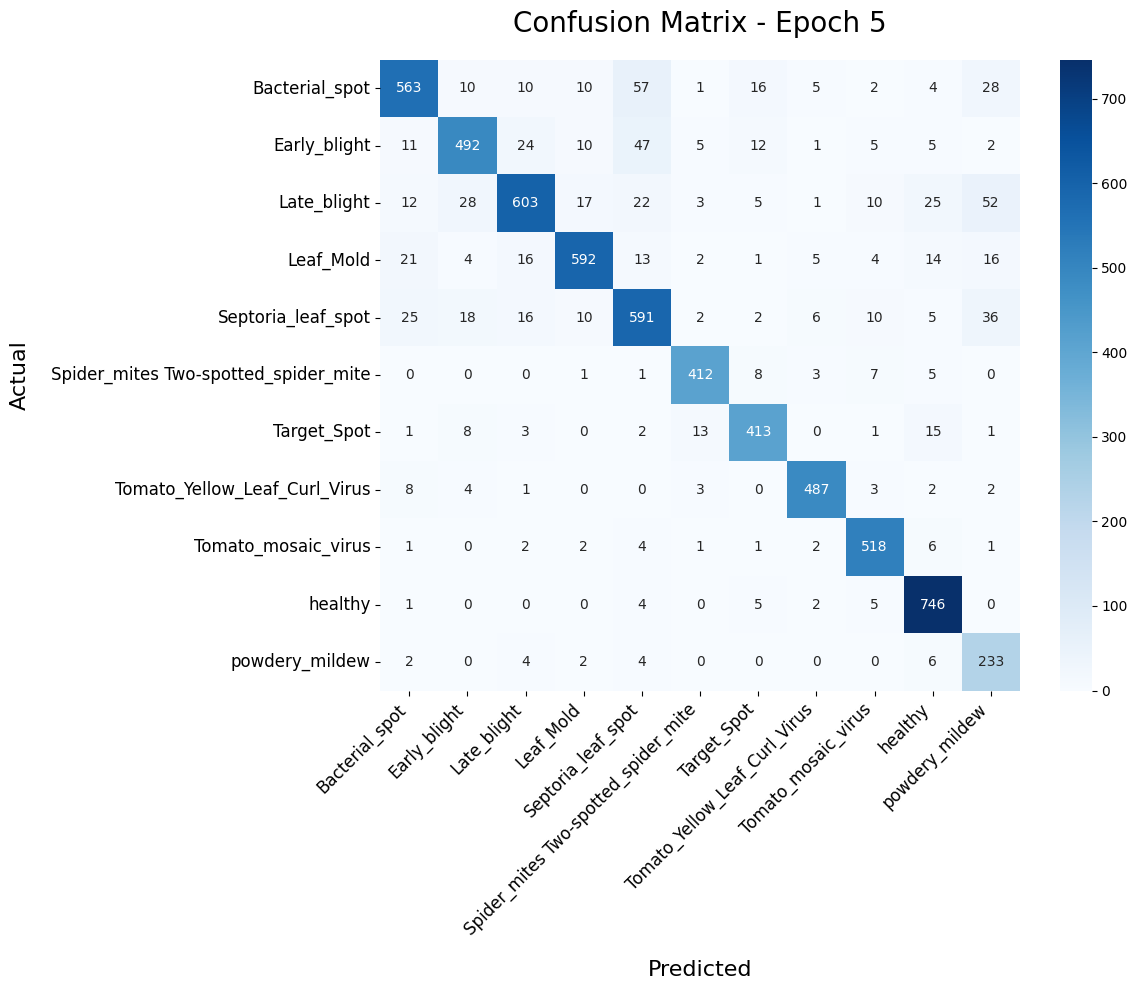

In [106]:
my_train_model(
    model=efficientnet_model,
    train_loader=train_image_loader,
    val_loader=validation_image_loader,
    criterion=criterion,
    scheduler=scheduler,
    optimizer=optimizer,
    class_names=train_and_validation_classes,
    epochs=5,
    save_path="models/efficientnet_feature_extraction.pth",
    patience=3
)

#### Full Fine-Tuning

Total Progress:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/20
----------


Total Progress:   5%|▌         | 1/20 [01:36<30:35, 96.59s/it, loss=0.0766]

Train Loss: 0.0963 | Val Loss: 0.0614 | Val Acc: 0.9782
Val F1 Weighted: 0.9782 | Val F1 Macro: 0.9786
Best Validation F1 Weighted: 0.9782
Epoch 2/20
----------


Total Progress:  10%|█         | 2/20 [03:12<28:55, 96.43s/it, loss=0.034]  

...

Train Loss: 0.0019 | Val Loss: 0.0414 | Val Acc: 0.9921
Val F1 Weighted: 0.9921 | Val F1 Macro: 0.9923
Best Validation F1 Weighted: 0.9926
Epoch 20/20
----------


Total Progress: 100%|██████████| 20/20 [33:48<00:00, 101.45s/it, loss=0.000201]
2026/02/19 22:41:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Train Loss: 0.0031 | Val Loss: 0.0434 | Val Acc: 0.9913
Val F1 Weighted: 0.9913 | Val F1 Macro: 0.9919
Best Validation F1 Weighted: 0.9926


2026/02/19 22:41:21 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/02/19 22:44:34 WARNING mlflow.utils.requirements_utils: Found torch version (2.9.1+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.9.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/02/19 22:46:35 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\hrichard\AppData\Local\Temp\tmpdvgtw67x\model\data, flavor: pytorch). Fall back to return ['torch==2.9.1'

🏃 View run youthful-fox-59 at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0/runs/8d070a6ebeda4e26830607bd933fd97d
🧪 View experiment at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0


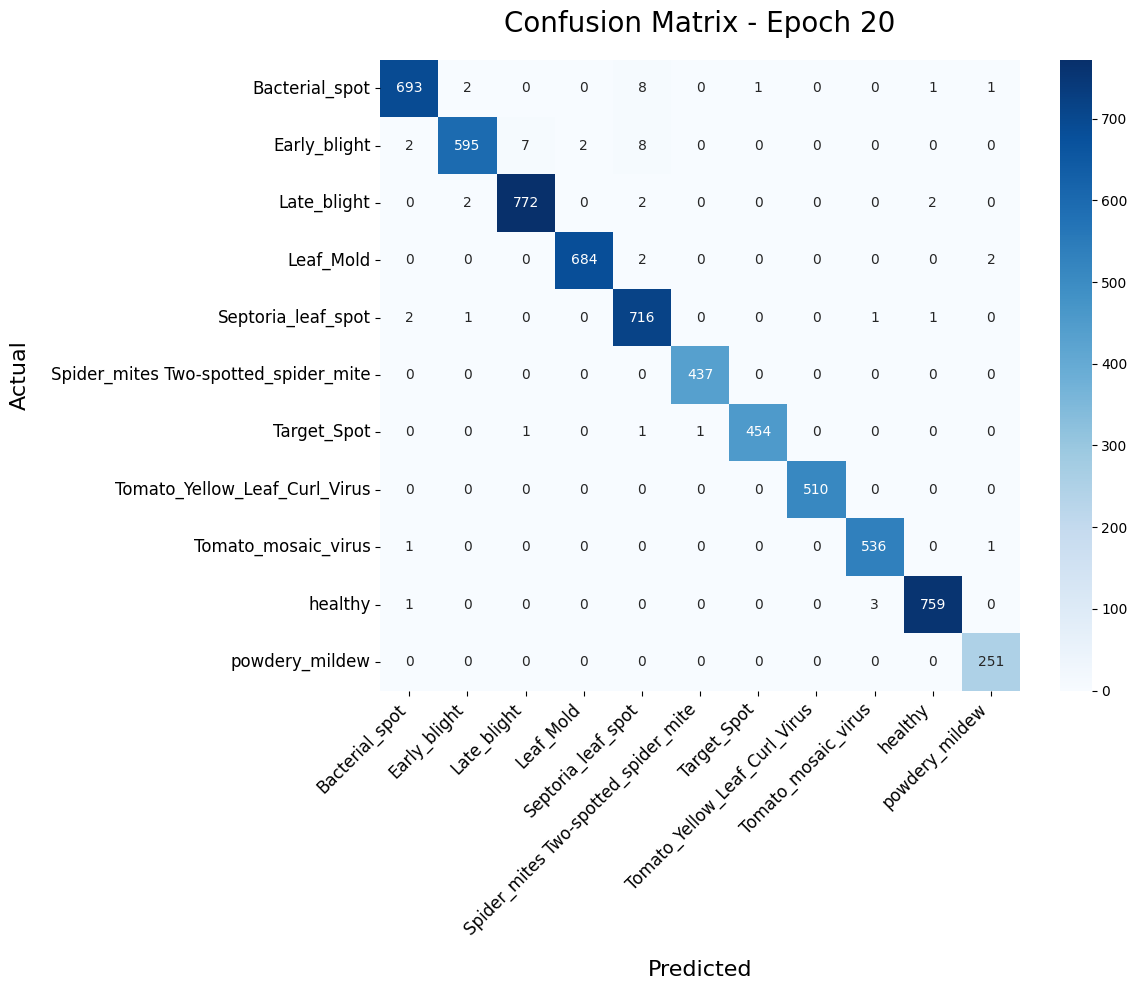

In [111]:
# 1. Unfreeze all layers
for param in efficientnet_model.parameters():
    param.requires_grad = True

# 2. Use a MUCH smaller Learning Rate
# We use 1e-4 (0.0001) so we don't "destroy" the pretrained weights
optimizer = optim.Adam(efficientnet_model.parameters(), lr=0.0001)

# 3. Keep the same scheduler or reset it
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# 4. Run for more epochs
custom_model, custom_history, custom_conf_mat = my_train_model(
    model=efficientnet_model,
    train_loader=train_image_loader,
    val_loader=validation_image_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    class_names=train_and_validation_classes,
    epochs=20, # Give it time to specialize
    save_path="models/efficientnet_full_finetuning.pth",
    patience=7  # More patience for fine-tuning
)

In [39]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [40]:
efficientnet_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

for name, layer in efficientnet_model.named_children():
    if name == 'classifier':
        print(f"Layer: {layer}")

Layer: Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [41]:
num_ftrs = efficientnet_model.classifier[1].in_features
efficientnet_model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(num_ftrs, num_train_classes)
    )

efficientnet_model.load_state_dict(torch.load("models/efficientnet_full_finetuning.pth"))

for name, layer in efficientnet_model.named_children():
    if name == 'classifier':
        print(f"Layer: {layer}")

Layer: Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1280, out_features=11, bias=True)
)


Loss on test set: 0.06419266598338513
Accuracy score on test set: 98.67%
Weighted F1 score on test set: 98.67%
Macro F1 score on test set: 98.81%
🏃 View run languid-pug-286 at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0/runs/bd6f99cd366044ec83b919f7a4ab4c6b
🧪 View experiment at: https://dagshub.com/RichardHolzhofer/tomato_disease_detection_project.mlflow/#/experiments/0


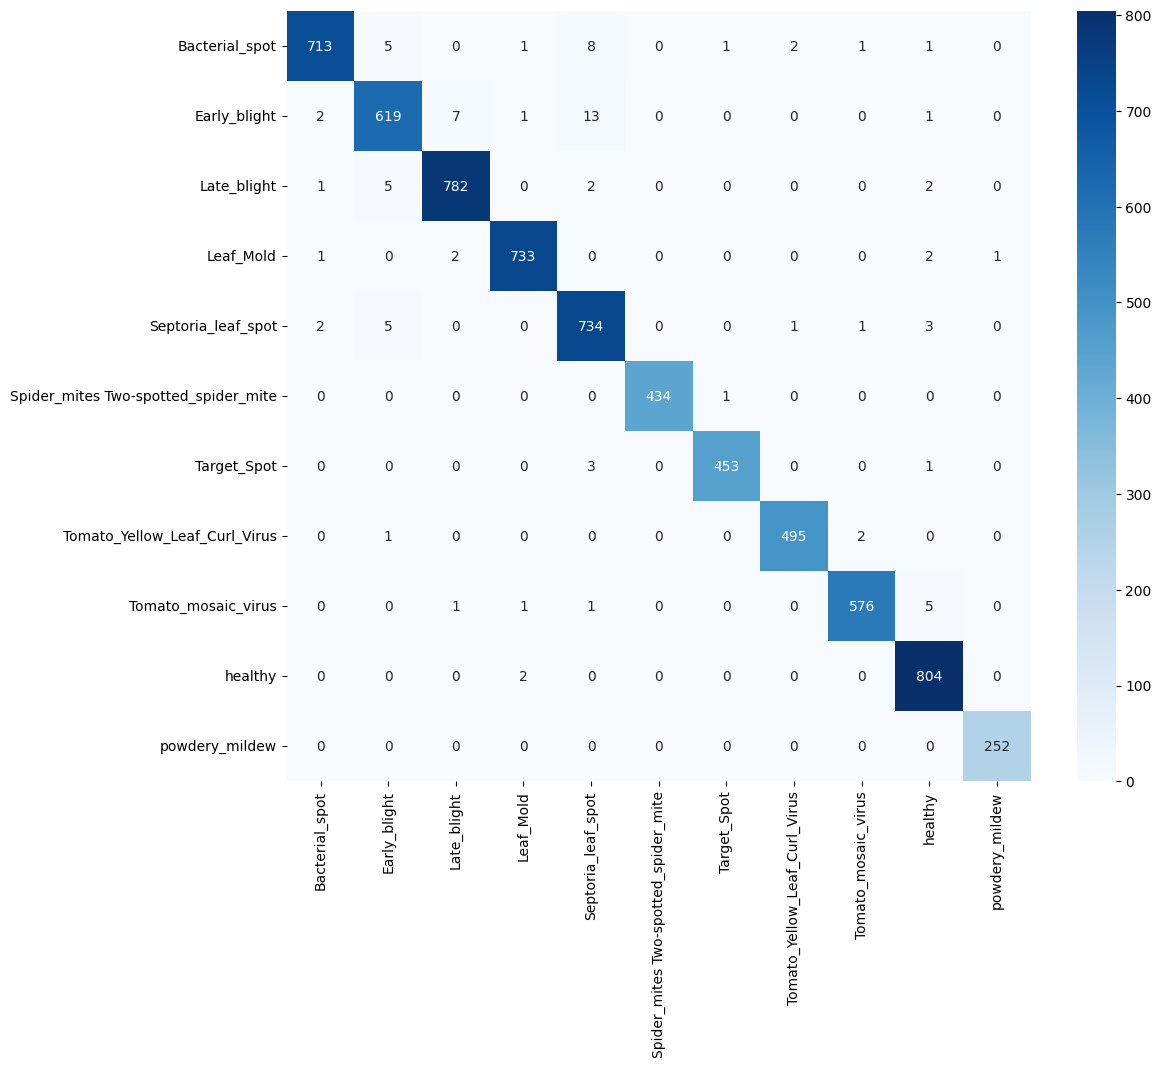

In [42]:
efficientnet_model.to(device)
weights_tensor = torch.tensor(train_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=weights_tensor).to(device)
evaluate_model(model=efficientnet_model, test_loader=test_image_loader, criterion=criterion)

In [44]:
print(summary(model=efficientnet_model, input_size=(3,256,256)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             864
       BatchNorm2d-2         [-1, 32, 128, 128]              64
              SiLU-3         [-1, 32, 128, 128]               0
            Conv2d-4         [-1, 32, 128, 128]             288
       BatchNorm2d-5         [-1, 32, 128, 128]              64
              SiLU-6         [-1, 32, 128, 128]               0
 AdaptiveAvgPool2d-7             [-1, 32, 1, 1]               0
            Conv2d-8              [-1, 8, 1, 1]             264
              SiLU-9              [-1, 8, 1, 1]               0
           Conv2d-10             [-1, 32, 1, 1]             288
          Sigmoid-11             [-1, 32, 1, 1]               0
SqueezeExcitation-12         [-1, 32, 128, 128]               0
           Conv2d-13         [-1, 16, 128, 128]             512
      BatchNorm2d-14         [-1, 16, 1

In [45]:
import time

efficientnet_model.eval()
dummy_input = torch.randn(1, 3, 256, 256).to(device)

# Warm up
for _ in range(10):
    _ = efficientnet_model(dummy_input)

# Measure
start_time = time.time()
with torch.inference_mode():
    for _ in range(100):
        _ = efficientnet_model(dummy_input)
end_time = time.time()

print(f"Average Inference Time: {(end_time - start_time) / 100 * 1000:.2f} ms per image")

Average Inference Time: 6.26 ms per image
